# Assignment 1


### Creating a data frame using lists, tuples, dictionaries


In [1]:
import pandas as pd
import numpy as np

In [3]:
l1 = ['Aryan','Himali','Swayam','Sobaan']
l2 = [90,89,56,98]
df = pd.DataFrame({'Name':l1,'Marks':l2})
df

,Name,Marks
0,Aryan,90
1,Himali,89
2,Swayam,56
3,Sobaan,98


In [5]:
data = [('Aryan', 95),
        ('Sobaan', 90),
        ('Himali', 80)
]

df2 = pd.DataFrame(data,columns=["Name","Marks"])
df2


,Name,Marks
0,Aryan,95
1,Sobaan,90
2,Himali,80


In [7]:
data = {'Name':["Aryan","himali","siya"],
        'Marks':[90,80,70]}

df3 = pd.DataFrame(data)
df3

,Name,Marks
0,Aryan,90
1,himali,80
2,siya,70


## Measures of central tendency


In [20]:
print ("mean is",df3['Marks'].mean())
print ("median is",df3['Marks'].median())
print ("mode is",df3['Marks'].max())
print ("standard deviation is",df3['Marks'].std())

mean is 80.0
median is 80.0
mode is 90
standard deviation is 10.0


In [21]:
import numpy as np

data = {'Name':['Alice','Bob','Charlie','Sobaan','Himali'],
        'Marks':[85,90,78,np.nan,80],
        'Age':[60,60,np.nan,60,np.nan]}

datapaneer = pd.DataFrame(data)

print("sum of all null values in marks is",datapaneer['Marks'].isnull().sum())
datapaneer['Marks']=datapaneer['Marks'].fillna(datapaneer['Marks'].mean())

datapaneer= datapaneer.dropna(subset=['Age'])
datapaneer

sum of all null values in marks is 1


,Name,Marks,Age
0,Alice,85.00,60.0
1,Bob,90.00,60.0
3,Sobaan,83.25,60.0


# Assignment 2


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [30]:
# Creating a DataFrame
data = {
    'Name': ['Aarav', 'Rohan', 'Kunal', 'Vikram', 'Aarav', 'Neha', 'Suresh', 'Pooja', 'Anita', 'Rahul'],
    'Age': [25, 30, 35, 40, 25, 22, np.nan, 29, 30, 31],
    'Salary': [50000, 60000, 70000, 80000, 50000, 45000, 52000, 58000, 61000, 63000],
    'Score': [85, 90, 95, np.nan, 85, 88, 92, 89, 91, 87],
    'Height': [165, 170, 175, 180, 165, 160, 172, 168, 171, 173],
    'Weight': [60, 70, 80, 90, 60, 55, 75, 65, 72, 74]
}
df = pd.DataFrame(data)
df

,Name,Age,Salary,Score,Height,Weight
0,Aarav,25.0,50000,85.0,165,60
1,Rohan,30.0,60000,90.0,170,70
2,Kunal,35.0,70000,95.0,175,80
3,Vikram,40.0,80000,NaN,180,90
4,Aarav,25.0,50000,85.0,165,60
5,Neha,22.0,45000,88.0,160,55
6,Suresh,NaN,52000,92.0,172,75
7,Pooja,29.0,58000,89.0,168,65
8,Anita,30.0,61000,91.0,171,72
9,Rahul,31.0,63000,87.0,173,74


In [32]:
print("Original Shape:", df.shape)
df.dropna(inplace=True)
df

Original Shape: (10, 6)


,Name,Age,Salary,Score,Height,Weight
0,Aarav,25.0,50000,85.0,165,60
1,Rohan,30.0,60000,90.0,170,70
2,Kunal,35.0,70000,95.0,175,80
4,Aarav,25.0,50000,85.0,165,60
5,Neha,22.0,45000,88.0,160,55
7,Pooja,29.0,58000,89.0,168,65
8,Anita,30.0,61000,91.0,171,72
9,Rahul,31.0,63000,87.0,173,74


In [34]:
df_unduplicated = df.drop_duplicates()
df_unduplicated

,Name,Age,Salary,Score,Height,Weight
0,Aarav,25.0,50000,85.0,165,60
1,Rohan,30.0,60000,90.0,170,70
2,Kunal,35.0,70000,95.0,175,80
5,Neha,22.0,45000,88.0,160,55
7,Pooja,29.0,58000,89.0,168,65
8,Anita,30.0,61000,91.0,171,72
9,Rahul,31.0,63000,87.0,173,74


In [36]:
df_normalized = df_unduplicated.copy()
paneerscaler = MinMaxScaler()
cols=['Age','Salary','Score','Height','Weight']
df_normalized[cols]=paneerscaler.fit_transform(df_normalized[cols])
df_normalized

,Name,Age,Salary,Score,Height,Weight
0,Aarav,0.230769,0.20,0.0,0.333333,0.20
1,Rohan,0.615385,0.60,0.5,0.666667,0.60
2,Kunal,1.000000,1.00,1.0,1.000000,1.00
5,Neha,0.000000,0.00,0.3,0.000000,0.00
7,Pooja,0.538462,0.52,0.4,0.533333,0.40
8,Anita,0.615385,0.64,0.6,0.733333,0.68
9,Rahul,0.692308,0.72,0.2,0.866667,0.76


In [37]:
df_normalized = df_unduplicated.copy()
paneerscaler = StandardScaler()
cols=['Age','Salary','Score','Height','Weight']
df_normalized[cols]=paneerscaler.fit_transform(df_normalized[cols])
df_normalized

,Name,Age,Salary,Score,Height,Weight
0,Aarav,-0.987218,-1.057734,-1.446728,-0.820067,-1.006764
1,Rohan,0.292509,0.241238,0.241121,0.242983,0.251691
2,Kunal,1.572236,1.540209,1.928971,1.306032,1.510147
5,Neha,-1.755054,-1.707220,-0.434019,-1.883116,-1.635992
7,Pooja,0.036564,-0.018557,-0.096449,-0.182237,-0.377537
8,Anita,0.292509,0.371135,0.578691,0.455593,0.503382
9,Rahul,0.548454,0.630929,-0.771589,0.880812,0.755073


In [44]:
bins = [0,30,70,100]
labels = ['Young','Adult','Old']
df_binned = df_unduplicated.copy()
df_binned['Age_Group'] = pd.cut(df_binned['Age'], bins = bins, labels = labels)
df_binned

,Name,Age,Salary,Score,Height,Weight,Age_Group
0,Aarav,25.0,50000,85.0,165,60,Young
1,Rohan,30.0,60000,90.0,170,70,Young
2,Kunal,35.0,70000,95.0,175,80,Adult
5,Neha,22.0,45000,88.0,160,55,Young
7,Pooja,29.0,58000,89.0,168,65,Young
8,Anita,30.0,61000,91.0,171,72,Young
9,Rahul,31.0,63000,87.0,173,74,Adult


In [50]:
pca = PCA(n_components=2)
features = df_unduplicated[cols]
pca_result = pca.fit_transform(features)
df_pca = pd.DataFrame(data = pca_result, columns=['PC1','PC2'])
df_pca

,PC1,PC2
0,-8142.863698,-2.286174
1,1857.144750,0.163469
2,11857.153197,2.613111
3,-13142.868156,2.454974
4,-142.860599,0.448351
5,2857.146799,0.545171
6,4857.147707,-3.938902


In [56]:
height = df_unduplicated['Height']
weight = df_unduplicated['Weight']
col_pc = np.corrcoef(height,weight)
print("Correlation coefficient is ",col_pc[0][1])

Correlation coefficient is  0.9861499344636824


In [ ]:
pc = df_unduplicated[['Height','Weight']].corr(method = 'pearson')
print("pearson corr is", pc)

pearson corr is          Height   Weight
Height  1.00000  0.98615
Weight  0.98615  1.00000


## Conclusion

Data preprocessing is a critical step in the data mining process. It involves cleaning, integrating, transforming, and reducing data to make it suitable for analysis. In this lab, we successfully demonstrated techniques for handling missing values, removing duplicates, normalizing data using Min-Max and Z-score methods, binning for data smoothing, and applying PCA for dimensionality reduction. We also explored correlation analysis using Pearson's method and visualized the relationships using heatmaps.

## FAQs

1. **Why do we need scaling?**
   Scaling ensures that features with different units and ranges contribute equally to the analysis, preventing features with larger magnitudes from dominating the model.

2. **Benefits and Techniques of Binning in Python**
   Binning smooths noisy data, handles outliers, and can improve model performance by grouping continuous values into discrete categories. Techniques include equal-width binning and equal-frequency binning.

3. **What is Data leakage, how to avoid any data leakage during the model testing process.**
   Data leakage occurs when information from the target variable is used to train the model. To avoid it, ensure that data preprocessing (like scaling) is fit only on the training set and then applied to the test set.

4. **Which technique we should use Normalization or Standardization?**
   Normalization (Min-Max) is useful when the data needs to be bounded (e.g., 0-1) and for algorithms like Neural Networks. Standardization (Z-score) is better when the data follows a Gaussian distribution and for algorithms like SVMs and Logistic Regression.

5. **What are the benefits of Correlation Analysis?**
   It helps in identifying relationships between variables, detecting multicollinearity, and selecting relevant features for the model.

6. **What is the significance of Correlation Analysis?**
   It quantifies the strength and direction of the linear relationship between two variables, aiding in understanding data structure and feature selection.

7. **What are the different kinds of correlation analysis? Discuss their strength and weakness.**
   - **Pearson:** Measures linear relationship. Sensitive to outliers.
   - **Spearman:** Measures monotonic relationship. Robust to outliers but less powerful for linear relationships.
   - **Kendall:** Measures ordinal association. computationally expensive but robust.

8. **What are the factors that affect a Correlation Analysis?**
   Outliers, non-linear relationships, restricted range of data, and heterogeneous subgroups can affect correlation analysis.

9. **Write a short note on**
   - **a. The correlation coefficient:** A statistical measure (r) that calculates the strength of the relationship between the relative movements of two variables. It ranges from -1 to +1.
   - **b. The p-value:** A probability measure that helps determine the significance of the results. A low p-value (typically < 0.05) indicates that the observed correlation is statistically significant.


# Assignmeent 3 Olap Cube


- Dimensions = Dimensions represent the qualitative data. They provide the context for your numbers and define how you want to slice, dice, or group your data.

Examples - Geography: Country or RegionCode (from the customers table).

    - People: EmployeeName (from the employees table).

    - Product: AlbumName or Artist (seen in the "Select a field" dropdown).

In an OLAP cube, you choose a Dimension when you want to answer the question: "By what?" (e.g., Sales by Country, Revenue by Artist).

- Levels are the organized steps within a Dimension that create a Hierarchy. They allow you to "drill down" from a broad summary to specific details.

For example if we're looking at an Album's Dimension:

Level 1 (Top): LabelName
Level 2 : Artist
Level 3 : AlbumName

For example, if you are looking at a Geography Dimension:

Level 1 (Top): Country (e.g., USA)
Level 2: RegionCode (e.g., West)
Level 3 (Bottom): City or CustomerID

- Types of Dimension
  1. Standard
  2. Time
  3. Parent-Child

Relational Dimension, for employee relations dimension level go to level -> ("first name") right click properties and then -> name value edit and insert > last name with -> &""&.

then click on add -> key -> value -> employee -> EmployeeId
-> parent -> value -> employee -> ReportsTo

- Measures = Measures represent the quantitative data. These are the actual numerical values or "facts" that you want to aggregate (sum, average, count, etc.) to see how your business is performing.

Examples - UnitPrice: To calculate average prices or total revenue.

    - Quantity: To calculate total items sold.


# Assignment 4


# Assignment 5


In [1]:
!pip install mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------- -------- 1.0/1.4 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.0 MB/s  0:00:00


In [18]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori,association_rules

transactions = [
    ['milk', 'bread', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['bread', 'butter']
]

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
features = pd.DataFrame(te_array,columns = te.columns_)
var1 = apriori(features,min_support=0.4,use_colnames=True)
var2 = association_rules(var1,metric= 'confidence',min_threshold=0.6)

print(var2)

  antecedents consequents  antecedent support  consequent support  support  \
0     (bread)    (butter)                 0.8                 0.8      0.6   
1    (butter)     (bread)                 0.8                 0.8      0.6   
2      (milk)     (bread)                 0.6                 0.8      0.4   
3      (milk)    (butter)                 0.6                 0.8      0.4   

   confidence      lift  representativity  leverage  conviction  \
0    0.750000  0.937500               1.0     -0.04         0.8   
1    0.750000  0.937500               1.0     -0.04         0.8   
2    0.666667  0.833333               1.0     -0.08         0.6   
3    0.666667  0.833333               1.0     -0.08         0.6   

   zhangs_metric  jaccard  certainty  kulczynski  
0      -0.250000      0.6  -0.250000    0.750000  
1      -0.250000      0.6  -0.250000    0.750000  
2      -0.333333      0.4  -0.666667    0.583333  
3      -0.333333      0.4  -0.666667    0.583333  


# Assignment 6


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("bank.csv")

In [4]:
df.info

<bound method DataFrame.info of        age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campa

In [5]:
df.describe

<bound method NDFrame.describe of        age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  cam

In [6]:
df.shape

(11162, 17)

In [8]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [10]:
x = df.drop('deposit',axis=1)
y = df['deposit']

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

x = pd.get_dummies(x)

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=5,
    min_samples_split=10,
    criterion='gini',
    random_state=42
)

model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
for depth in [3,5,7,9]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train,Y_train)
    y_pred = model.predict(X_test)
    print(accuracy_score(Y_test,y_pred))

0.7693685624720108
0.7948947604120018
0.799373040752351
0.8069861173309449


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 80.70%


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred))

print("\nClassification Report:\n", classification_report(Y_test, y_pred))


Confusion Matrix:
 [[896 270]
 [161 906]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81      1166
           1       0.77      0.85      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [ ]:
plt.figure(figsize=(25, 12))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    rounded=True,
    fontsize=8
)

# Assingment 7


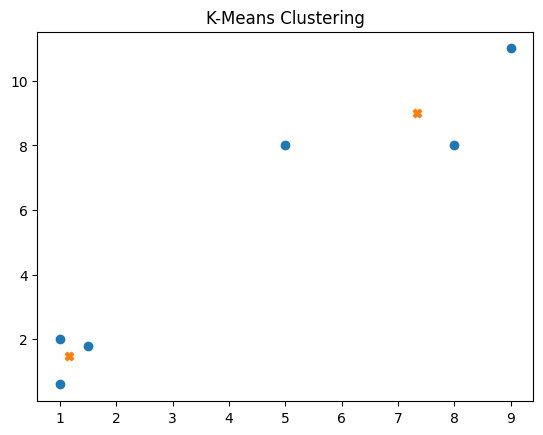

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample data
X = np.array([
    [1, 2], [1.5, 1.8], [5, 8],
    [8, 8], [1, 0.6], [9, 11]
])

# Create KMeans model
kmeans = KMeans(n_clusters=2, random_state=42)

# Fit the model
kmeans.fit(X)

# Get labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plotting
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X')

plt.title("K-Means Clustering")
plt.show()